# Problema computacional: Diagnóstico de haces relativistas mediante radiación sincrotrón

**Autores:** Melanny Silva, Juan Montoya

## 1. Enunciado del problema 

Este bloque fija la pregunta evaluada, separa el problema directo del problema inverso y declara el alcance del modelo antes de entrar en la teoría y en la solución computacional.

### 1.1 Pregunta central

¿Puede reconstruirse la energía relativista y estimarse la divergencia angular de un haz de electrones a partir del patrón angular y del contenido espectral de la radiación emitida cuando el haz es curvado por un campo magnético?

La motivación física es la transición de régimen: de un haz tipo CRT a un haz relativista de sincrotrón. El notebook usa esa transición como motivación narrativa, pero el objetivo físico principal es diagnóstico inverso: inferir energía y divergencia angular a partir de observables de radiación.

### 1.2 Problema directo

En el problema directo se parte de la energía cinética `K` o de `gamma`, junto con un campo magnético de referencia `B_ref`, y se calculan trayectoria, patrón angular instantáneo, FWHM, potencia absoluta y escala espectral.

| Problema | Datos de entrada | Resultado calculado |
|---|---|---|
| Directo | Energía cinética `K` o `gamma`, campo `B_ref` | Trayectoria, patrón angular instantáneo, FWHM, potencia absoluta y escala espectral. |

### 1.3 Problema inverso

En el problema inverso se parte de observables sintéticos `Delta theta_obs` y `m_c_obs` para reconstruir `gamma`, la energía cinética `K` y la divergencia angular efectiva del haz.

| Problema | Datos de entrada | Resultado calculado |
|---|---|---|
| Inverso | Observables sintéticos `Delta theta_obs` y `m_c_obs` | Reconstrucción de `gamma`, energía cinética `K` y divergencia angular del haz. |

La consistencia entre el observable angular y el observable espectral funciona como prueba diagnóstica del modelo de haz monoenergético con divergencia simple.

### 1.4 Objetivos computacionales

A. Calcular la cinemática en campo magnético: $K$, $\gamma$, $\beta$, $v$, $\omega_0$ y $R$.

B. Evaluar el patrón angular para energías desde $20\,\mathrm{keV}$ hasta $1\,\mathrm{GeV}$ con la distribución angular instantánea de Liénard-Wiechert.

C. Medir el FWHM del lóbulo principal y calibrarlo como proporcional a $1/\gamma$ mediante $A_{fit}/\gamma$.

D. Estimar escalas espectrales con $m_c\sim\gamma^3$ y $\omega_c=(3/2)\gamma^3\omega_0$, distinguiendo escala diagnóstica de espectro exacto.

E. Resolver el problema inverso: reconstruir energía y estimar divergencia angular por desconvolución cuadrática del ancho observado.

### 1.5 Alcance y limitaciones iniciales

El modelo usa una distribución angular instantánea de Liénard-Wiechert, una órbita circular ideal en campo magnético uniforme y observables sintéticos para probar la inversión. La FFT incluida es cualitativa: muestra que pulsos temporales más estrechos contienen armónicos más altos, pero no reemplaza el espectro sincrotrón completo.

El CRT queda como apéndice conceptual integrado en la sección de análisis y aplicaciones: ilustra deflexión por fuerza de Lorentz y emisión visible por impacto en fósforo, no una fuente práctica de radiación sincrotrón.

| Bloque evaluado | Función dentro del notebook |
|---|---|
| 1. Enunciado del problema | Define pregunta, problema directo, problema inverso, objetivos y alcance. |
| 2. Teoría | Presenta cinemática, radiación, tiempo retardado, escalas angulares/espectrales y unidades. |
| 3. Solución de las partes del problema | Contiene el desarrollo computacional, figuras, tablas y reconstrucción inversa. |
| 4. Análisis y aplicaciones | Interpreta los regímenes, integra la aplicación CRT y resume limitaciones/conclusiones. |
| 5. Referencias | Lista las fuentes usadas para la teoría y las constantes físicas. |


## 2. Teoría 

Este bloque reúne la base física necesaria antes de ejecutar las celdas computacionales: cinemática relativista, movimiento circular, radiación de cargas aceleradas, tiempo retardado y escalas diagnósticas.

### 2.1 Cinemática relativista

La energía cinética fija el factor de Lorentz y la velocidad adimensional mediante

$$\gamma=1+\frac{K}{m_e c^2},\qquad \beta=\sqrt{1-\frac{1}{\gamma^2}},\qquad v=\beta c.$$

Estas variables conectan la energía del haz con los observables angulares y espectrales usados después en el problema inverso.

### 2.2 Movimiento circular en campo magnético

Para una carga relativista curvada por un campo magnético uniforme, la frecuencia orbital y el radio de curvatura usados en el problema directo son

$$\omega_0=\frac{eB}{\gamma m_e},\qquad R=\frac{\beta c}{\omega_0}.$$

Con `B_ref` fijo, aumentar la energía aumenta $\gamma$ y modifica simultáneamente la escala temporal orbital y el radio de la trayectoria.

### 2.3 Radiación de Larmor y límite no relativista

La electrodinámica clásica describe la radiación de cargas aceleradas a partir de potenciales retardados. En el régimen no relativista, la radiación de una carga acelerada tiene el patrón dipolar de Larmor:

$$
\frac{dP}{d\Omega}\propto \sin^2\alpha,
$$

donde $\alpha$ es el ángulo entre la dirección de observación y la aceleración, no necesariamente el ángulo respecto de la velocidad. En este notebook se fija $\boldsymbol\beta$ sobre $x$ y $\dot{\boldsymbol\beta}$ sobre $y$; por lo tanto, en el corte orbital donde $\theta$ se mide desde la velocidad instantánea, la referencia no relativista es

$$
P_{Larmor}(\theta)\propto 1-(\mathbf n\cdot\hat{\mathbf a})^2=\cos^2\theta.
$$

La potencia total contextual es $P=q^2a^2/(6\pi\epsilon_0c^3)$ en SI. Esta forma es útil como referencia angular, pero no describe el beaming relativista.

### 2.4 Distribución angular relativista de Liénard-Wiechert

En la formulación de Liénard-Wiechert, el campo observado en un instante se calcula desde el estado retardado de la partícula; de allí se separa el campo ligado a la carga del campo radiativo que transporta energía hacia el infinito.

Para una carga relativista, la distribución angular instantánea usada en el notebook es

$$
\frac{dP}{d\Omega}=\frac{q^2}{16\pi^2\epsilon_0 c}\frac{\left|\mathbf n\times\left[(\mathbf n-\boldsymbol\beta)\times\dot{\boldsymbol\beta}\right]\right|^2}{(1-\mathbf n\cdot\boldsymbol\beta)^5}.
$$

Esta expresión explica la concentración de radiación cerca de la dirección de movimiento cuando $\gamma$ crece.

### 2.5 Tiempo retardado

La radiación observada no corresponde a la posición instantánea de la partícula sino al estado retardado compatible con la distancia de propagación. La relación geométrica es

$$
t_{obs}=t_{ret}+\frac{|\mathbf r_{obs}-\mathbf r_q(t_{ret})|}{c}.
$$

Esta diferencia de tiempo se traduce en una fase observada distinta de la fase orbital instantánea.

### 2.6 Escala angular relativista: Delta theta ~ 1/gamma

La apertura angular del lóbulo relativista se estrecha con la energía. En el desarrollo computacional no se impone una constante universal: se mide el FWHM y se calibra como $A_{fit}/\gamma$, porque el coeficiente depende de la definición operativa del ancho y de la geometría del corte.

### 2.7 Escala espectral: mc ~ gamma^3

La escala armónica diagnóstica se toma como $m_c\sim\gamma^3$ y la escala crítica convencional como

$$\omega_c=\frac{3}{2}\gamma^3\omega_0.$$

Aquí $m_c$ y $\omega_c$ se usan como escalas de diagnóstico. No son un sustituto del cálculo espectral completo ni un conteo exacto de líneas dominantes.

### 2.8 Unidades SI vs gaussianas

Los cálculos numéricos están en SI. Algunas referencias presentan fórmulas en unidades gaussianas, por lo que no se mezclan convenciones dentro de las rutinas numéricas. Milton & Schwinger, Jackson y Griffiths se usan como guías de electrodinámica clásica; NIST/CODATA se usa para las constantes físicas.

Hay que distinguir dos niveles durante la lectura del notebook:

| Nivel | Qué describe | Qué no describe por sí solo |
|---|---|---|
| Distribución angular instantánea | Cómo se reparte $dP/d\Omega$ para una posición, velocidad y aceleración retardadas dadas. | El espectro completo acumulado en una órbita. |
| Contenido espectral | Cómo se distribuye la radiación en armónicos o frecuencias observadas. | No se obtiene de una única fotografía angular; requiere evolución temporal y geometría de observación. |

El espectro sincrotrón completo requiere la teoría armónica con funciones de Bessel; por eso las FFT de este notebook son visualizaciones fenomenológicas de pulsos estrechos y no sustituyen el cálculo espectral completo.


## 3. Solución de las partes del problema

### 3.1 Preparación computacional y reproducibilidad

Se usan constantes SI y figuras reproducibles en `figures/`. El notebook puede ejecutarse desde su propio directorio o desde la raíz del repositorio; en este segundo caso cambia al directorio del notebook antes de crear las figuras.


In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path("Python/electrodos/Electro2")
if NOTEBOOK_DIR.exists() and (NOTEBOOK_DIR / "electro2.ipynb").exists():
    os.chdir(NOTEBOOK_DIR)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

c = 299_792_458.0
m_e = 9.109_383_7015e-31
e_abs = 1.602_176_634e-19
epsilon0 = 8.854_187_8128e-12
mc2_eV = m_e * c**2 / e_abs

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

rng = np.random.default_rng(20260707)

def savefig(name):
    plt.savefig(FIG_DIR / name, bbox_inches="tight")


def gamma_from_kinetic_energy(K_eV):
    """Factor relativista para energía cinética electrónica en eV."""
    return 1.0 + np.asarray(K_eV, dtype=float) / mc2_eV


def kinetic_energy_from_gamma(gamma):
    """Energía cinética electrónica en eV a partir de gamma."""
    return (np.asarray(gamma, dtype=float) - 1.0) * mc2_eV


def beta_from_gamma(gamma):
    """Velocidad adimensional beta=v/c a partir de gamma."""
    gamma = np.asarray(gamma, dtype=float)
    inside = np.maximum(0.0, 1.0 - 1.0 / gamma**2)
    return np.sqrt(inside)


def orbital_frequency(B_T, gamma):
    """Frecuencia angular orbital SI para v perpendicular a B."""
    return e_abs * B_T / (np.asarray(gamma, dtype=float) * m_e)


def orbit_radius(beta, omega0):
    """Radio de curvatura R=v/omega0."""
    return np.asarray(beta, dtype=float) * c / np.asarray(omega0, dtype=float)


def omega_critical(gamma, omega0):
    """Escala crítica omega_c = (3/2) gamma^3 omega0."""
    return (3.0 / 2.0) * np.asarray(gamma, dtype=float)**3 * np.asarray(omega0, dtype=float)


def absolute_power_si(B_T, gamma, beta):
    """Potencia total radiada por carga relativista curvada por campo magnético uniforme."""
    return e_abs**4 * B_T**2 * np.asarray(gamma, dtype=float)**2 * np.asarray(beta, dtype=float)**2 / (6.0 * np.pi * epsilon0 * m_e**2 * c)


def format_energy(K_eV):
    if K_eV >= 1e9:
        return f"{K_eV/1e9:g} GeV"
    if K_eV >= 1e6:
        return f"{K_eV/1e6:g} MeV"
    return f"{K_eV/1e3:g} keV"

assert gamma_from_kinetic_energy(0) == 1
assert beta_from_gamma(1) == 0


In [2]:
def directions_from_angles(theta, phi=0.0):
    theta = np.asarray(theta, dtype=float)
    phi = np.asarray(phi, dtype=float)
    return np.stack([
        np.cos(theta),
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
    ], axis=-1)


def larmor_reference(theta, phi=0.0):
    """Patrón Larmor no relativista respecto de la aceleración, no de la velocidad."""
    n = directions_from_angles(theta, phi)
    a_hat = np.array([0.0, 1.0, 0.0])
    y = 1.0 - np.sum(n * a_hat, axis=-1)**2
    y = np.maximum(y, 0.0)
    peak = np.nanmax(y)
    return y / peak if peak > 0 else y


def angular_power_vectors(n, gamma=1.0, beta_dot_scale=1.0):
    """Distribución angular instantánea para direcciones vectoriales n[..., 3]."""
    n = np.asarray(n, dtype=float)
    gamma = float(gamma)
    beta = float(beta_from_gamma(gamma))
    beta_vec = np.array([beta, 0.0, 0.0])
    beta_dot = np.array([0.0, beta_dot_scale, 0.0])
    cross_inner = np.cross(n - beta_vec, beta_dot)
    numerator = np.sum(np.cross(n, cross_inner)**2, axis=-1)
    denom = np.maximum(1e-300, 1.0 - np.sum(n * beta_vec, axis=-1))**5
    prefactor = e_abs**2 / (16.0 * np.pi**2 * epsilon0 * c)
    return prefactor * numerator / denom


def angular_power(theta, phi=0.0, gamma=1.0, beta_dot_scale=1.0):
    """Distribución angular instantánea Liénard-Wiechert para beta en x y beta_dot en y."""
    n = directions_from_angles(theta, phi)
    return angular_power_vectors(n, gamma=gamma, beta_dot_scale=beta_dot_scale)


def normalized_angular_power(theta, phi=0.0, gamma=1.0):
    values = angular_power(theta, phi=phi, gamma=gamma, beta_dot_scale=1.0)
    peak = np.nanmax(values)
    return values / peak if peak > 0 else values


def adaptive_fwhm(gamma, theta_max=None, n_points=5001):
    """FWHM angular del lóbulo delantero alrededor de theta=0 usando refinamiento local."""
    gamma = float(gamma)
    if theta_max is None:
        theta_max = min(np.pi, max(0.08, 12.0 / gamma))
    theta = np.linspace(-theta_max, theta_max, n_points)
    y = normalized_angular_power(np.abs(theta), gamma=gamma)
    y = y / np.max(y)
    center = int(np.argmax(y))
    half = 0.5

    def crossing(side):
        if side == "left":
            segment = np.where(y[:center] <= half)[0]
            if len(segment) == 0:
                return theta[0]
            i0 = segment[-1]
            i1 = i0 + 1
        else:
            segment = np.where(y[center:] <= half)[0]
            if len(segment) == 0:
                return theta[-1]
            i1 = center + segment[0]
            i0 = i1 - 1
        x0, x1 = theta[i0], theta[i1]
        y0, y1 = y[i0], y[i1]
        if y1 == y0:
            return x1
        return x0 + (half - y0) * (x1 - x0) / (y1 - y0)

    return crossing("right") - crossing("left")

assert adaptive_fwhm(80) < adaptive_fwhm(20) * 1.1


### 3.2 Problema directo: cinemática y trayectoria

Se evalúan cinco energías representativas con un campo magnético de referencia fijo `B_ref = 0.01 T`, usado para comparar escalas cinemáticas y radiativas bajo el mismo campo. La relación usada es

$$\gamma=1+\frac{K}{m_e c^2},\qquad \beta=\sqrt{1-\frac{1}{\gamma^2}},\qquad \omega_0=\frac{eB}{\gamma m_e},\qquad R=\frac{\beta c}{\omega_0}.$$

B_ref=0.01 T es un campo de referencia para comparar escalas de curvatura. La figura no propone dibujar órbitas completas reales; muestra cómo, para una longitud común de imán, las energías bajas se curvan más y las energías altas se aproximan a una trayectoria recta.


B_ref = 0.01 T
K        gamma       beta       omega0 [rad/s]     R [m]        m_c=gamma^3      omega_c [rad/s]
 20 keV     1.0391   0.271866       1.6926e+09  4.8153e-02      1.1221e+00       2.8488e+09
100 keV     1.1957   0.548221       1.4710e+09  1.1173e-01      1.7095e+00       3.7718e+09
  1 MeV     2.9570   0.941079       5.9481e+08  4.7432e-01      2.5854e+01       2.3068e+10
100 MeV   196.6951   0.999987       8.9419e+06  3.3526e+01      7.6099e+06       1.0207e+14
  1 GeV  1957.9512   1.000000       8.9830e+05  3.3373e+02      7.5059e+09       1.0114e+16


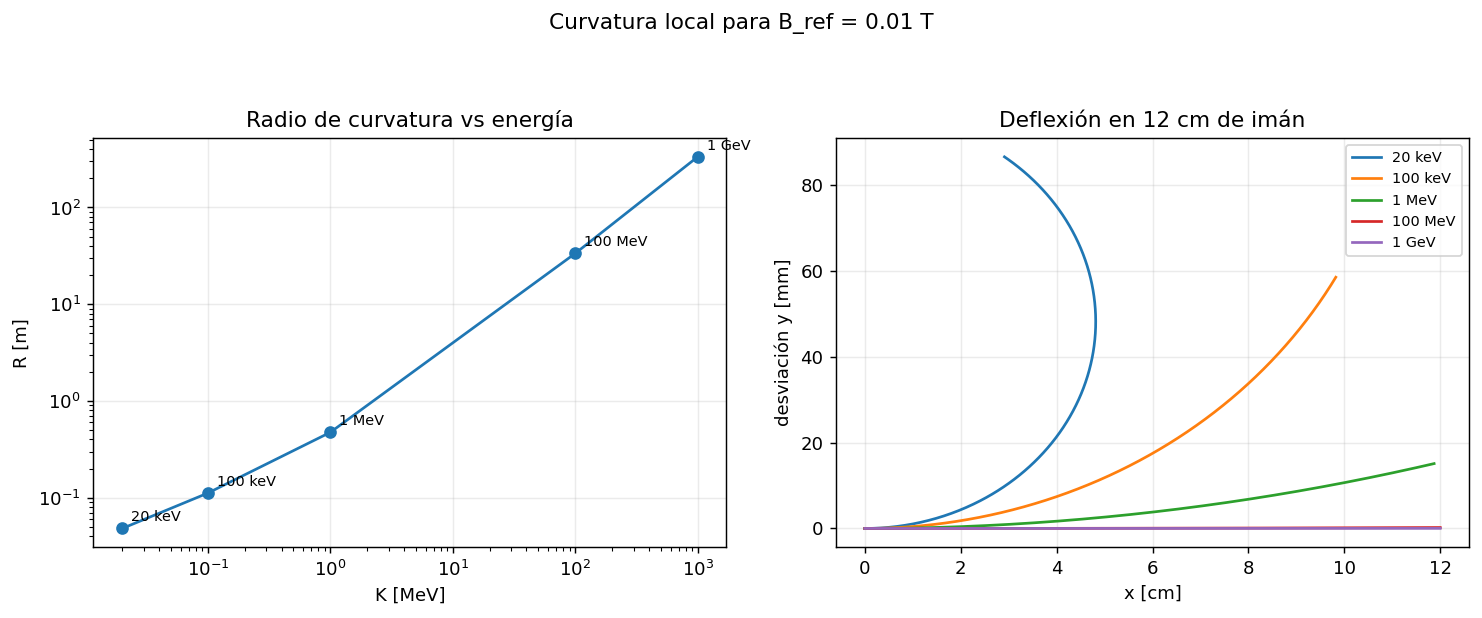

In [3]:
energies_eV = np.array([20e3, 100e3, 1e6, 100e6, 1e9])
energy_labels = [format_energy(K) for K in energies_eV]
B_ref = 0.01

gammas_E = gamma_from_kinetic_energy(energies_eV)
betas_E = beta_from_gamma(gammas_E)
omega0_E = orbital_frequency(B_ref, gammas_E)
radii_E = orbit_radius(betas_E, omega0_E)
mc_E = gammas_E**3
omega_c_E = omega_critical(gammas_E, omega0_E)

print(f"B_ref = {B_ref:g} T")
print("K        gamma       beta       omega0 [rad/s]     R [m]        m_c=gamma^3      omega_c [rad/s]")
for row in zip(energy_labels, gammas_E, betas_E, omega0_E, radii_E, mc_E, omega_c_E):
    print(f"{row[0]:>7} {row[1]:10.4f} {row[2]:10.6f} {row[3]:16.4e} {row[4]:11.4e} {row[5]:15.4e} {row[6]:16.4e}")

fig, (ax_scale, ax_bend) = plt.subplots(1, 2, figsize=(11.5, 4.8))

ax_scale.loglog(energies_eV / 1e6, radii_E, marker="o")
for label, K, R in zip(energy_labels, energies_eV, radii_E):
    ax_scale.annotate(label, (K / 1e6, R), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax_scale.set_xlabel("K [MeV]")
ax_scale.set_ylabel("R [m]")
ax_scale.set_title("Radio de curvatura vs energía")

s_max = 0.12
s = np.linspace(0, s_max, 500)
for label, R in zip(energy_labels, radii_E):
    x = R * np.sin(s / R)
    y = R * (1 - np.cos(s / R))
    ax_bend.plot(x * 100, y * 1000, label=label)
ax_bend.set_xlabel("x [cm]")
ax_bend.set_ylabel("desviación y [mm]")
ax_bend.set_title("Deflexión en 12 cm de imán")
ax_bend.legend(fontsize=8)

fig.suptitle("Curvatura local para B_ref = 0.01 T")
fig.tight_layout(rect=[0, 0, 1, 0.92])
savefig("trajectory_direct_problem.png")
plt.show()


### 3.3 Patrón angular de radiación

La comparación no relativista debe hacerse contra el patrón de Larmor medido desde la aceleración. Como aquí $\boldsymbol\beta\parallel\hat{x}$ y $\dot{\boldsymbol\beta}\parallel\hat{y}$, el corte orbital parametrizado por $\theta$ desde la velocidad usa

$$
P_{Larmor}\propto 1-(\mathbf n\cdot\hat{\mathbf a})^2,
$$

que en este corte coincide con $\cos^2\theta$. Esto evita la confusión de graficar $\sin^2\theta$ respecto de la velocidad. En las gráficas se normaliza cada curva por su máximo para comparar forma, no potencia absoluta.


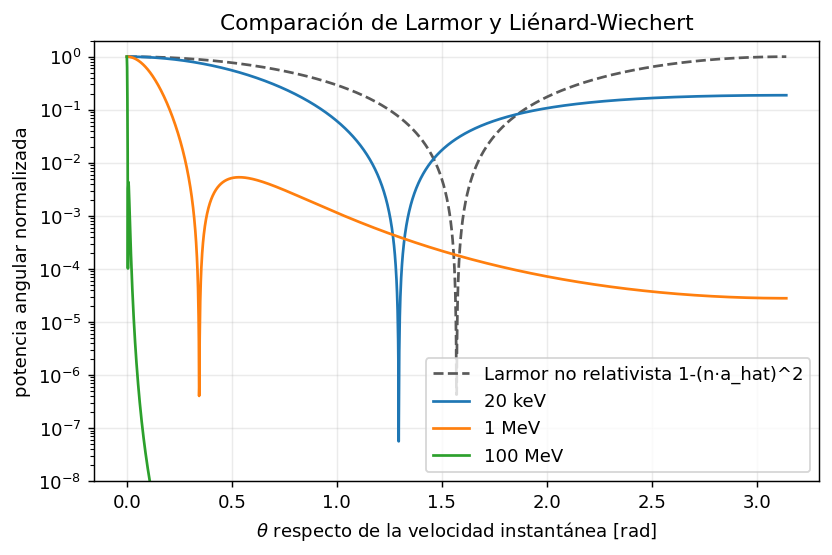

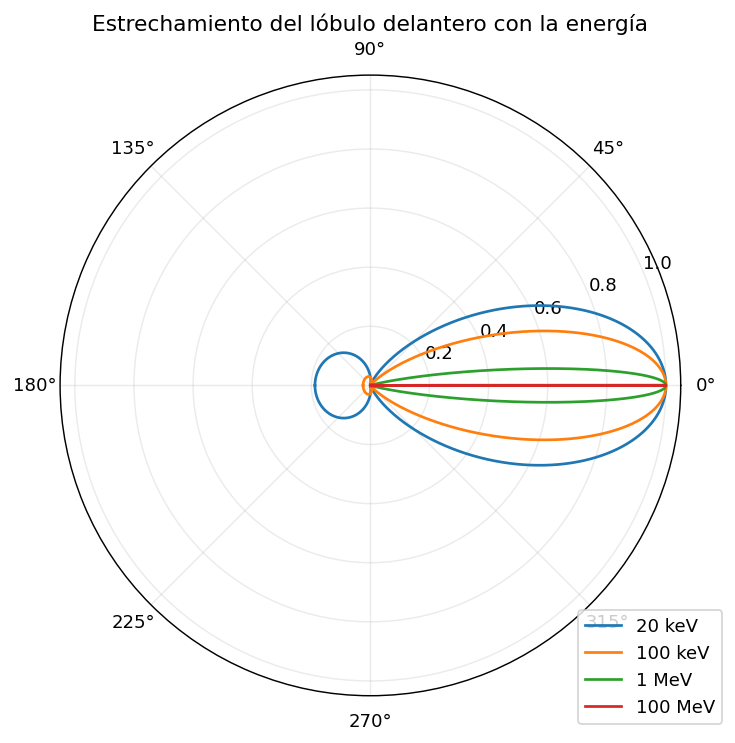

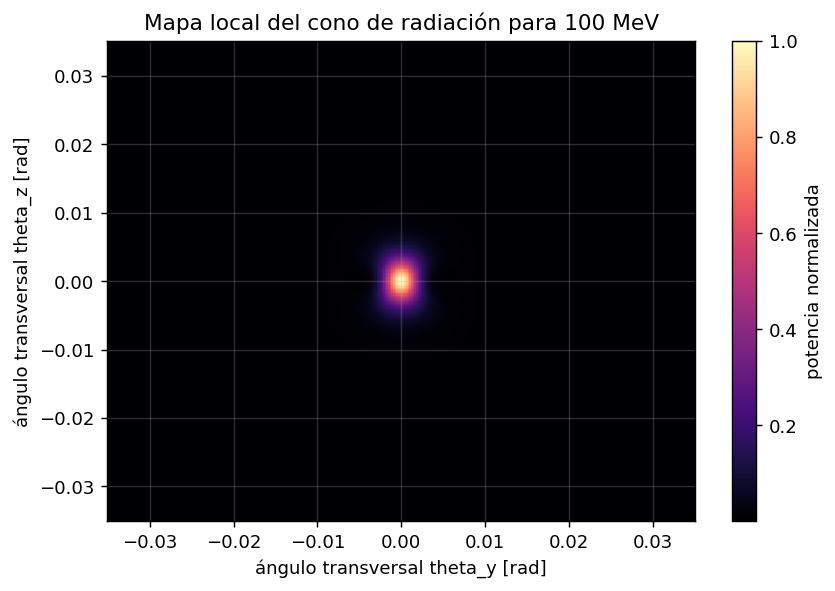

In [4]:
theta = np.linspace(0, np.pi, 2400)
larmor = larmor_reference(theta)
larmor_plot = np.clip(larmor, 1e-12, None)

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(theta, larmor_plot, "--", color="0.35", label="Larmor no relativista 1-(n·a_hat)^2")
for K, label in zip([20e3, 1e6, 100e6], ["20 keV", "1 MeV", "100 MeV"]):
    g = gamma_from_kinetic_energy(K)
    ax.plot(theta, normalized_angular_power(theta, gamma=g), label=label)
ax.set_yscale("log")
ax.set_ylim(1e-8, 2)
ax.set_xlabel(r"$\theta$ respecto de la velocidad instantánea [rad]")
ax.set_ylabel("potencia angular normalizada")
ax.set_title("Comparación de Larmor y Liénard-Wiechert")
ax.legend()
savefig("angular_model_comparison.png")
plt.show()

fig = plt.figure(figsize=(7.0, 6.2))
ax = fig.add_subplot(111, projection="polar")
for K, label in zip(energies_eV[:-1], energy_labels[:-1]):
    g = gamma_from_kinetic_energy(K)
    th = np.linspace(-np.pi, np.pi, 4000)
    ax.plot(th, normalized_angular_power(np.abs(th), gamma=g), label=label)
ax.set_title("Estrechamiento del lóbulo delantero con la energía")
ax.set_rlim(0, 1.05)
ax.legend(loc="lower left", bbox_to_anchor=(0.82, -0.06))
savefig("polar_beaming_energy_comparison.png")
plt.show()

K_heat = 100e6
g_heat = gamma_from_kinetic_energy(K_heat)
theta_y = np.linspace(-0.035, 0.035, 360)
theta_z = np.linspace(-0.035, 0.035, 360)
THY, THZ = np.meshgrid(theta_y, theta_z)
n_local = np.stack([np.ones_like(THY), THY, THZ], axis=-1)
n_local /= np.linalg.norm(n_local, axis=-1, keepdims=True)
Z = angular_power_vectors(n_local, gamma=g_heat)
Z /= Z.max()
fig, ax = plt.subplots(figsize=(7.3, 4.8))
im = ax.pcolormesh(theta_y, theta_z, Z, shading="auto", cmap="magma")
fig.colorbar(im, ax=ax, label="potencia normalizada")
ax.set_xlabel("ángulo transversal theta_y [rad]")
ax.set_ylabel("ángulo transversal theta_z [rad]")
ax.set_title("Mapa local del cono de radiación para 100 MeV")
savefig("angular_heatmap_100MeV.png")
plt.show()


### 3.4 Superficies angulares 3D

La superficie 3D muestra la misma distribución angular instantánea, pero evita reducir toda la información a un corte polar. Se toma un instante de movimiento circular con $\boldsymbol\beta$ en $x$ y $\dot{\boldsymbol\beta}$ en $y$.

La distancia radial de la superficie es una visualización normalizada de intensidad, no una frontera material. El cambio importante es cualitativo: al subir de $20\,\mathrm{keV}$ a $1\,\mathrm{MeV}$ y luego a $100\,\mathrm{MeV}$, la emisión pasa de un patrón ancho a un lóbulo delantero estrecho.


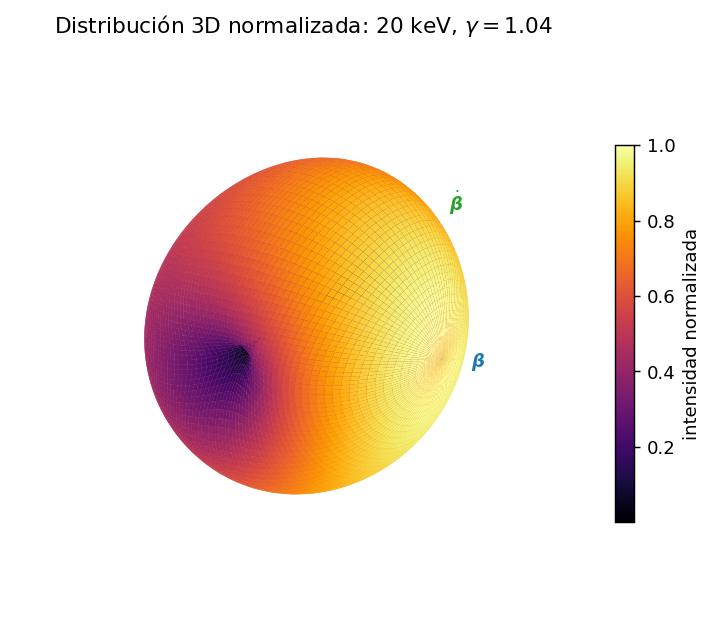

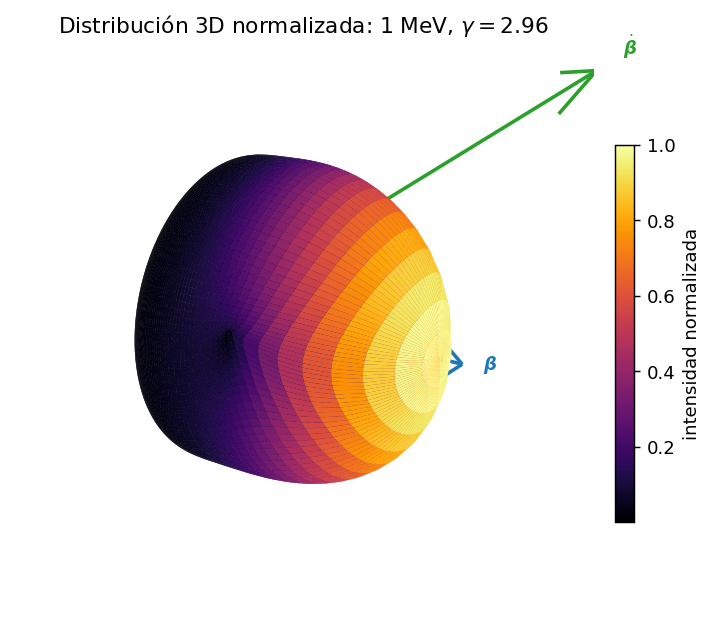

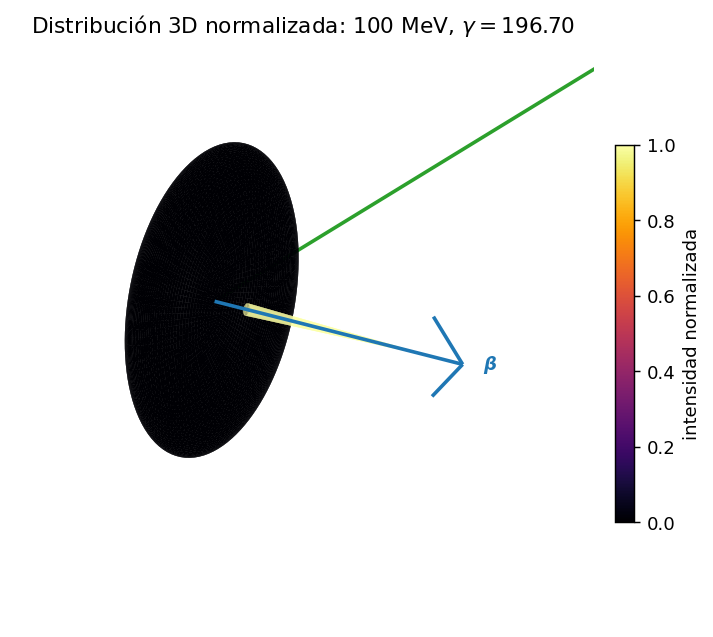

In [5]:
theta_surface = np.linspace(0, np.pi, 90)
phi_surface = np.linspace(-np.pi, np.pi, 120)
TH_s, PH_s = np.meshgrid(theta_surface, phi_surface)
n_surface = directions_from_angles(TH_s, PH_s)


def plot_angular_surface(K_eV, filename):
    gamma = gamma_from_kinetic_energy(K_eV)
    P = angular_power_vectors(n_surface, gamma=gamma)
    Pn = P / P.max()
    radius = 0.15 + Pn**0.35
    X = radius * n_surface[..., 0]
    Y = radius * n_surface[..., 1]
    Z = radius * n_surface[..., 2]

    fig = plt.figure(figsize=(7.2, 5.8))
    ax = fig.add_subplot(111, projection="3d")
    colors = plt.cm.inferno(Pn**0.45)
    ax.plot_surface(
        X,
        Y,
        Z,
        facecolors=colors,
        rstride=1,
        cstride=1,
        linewidth=0,
        antialiased=True,
        shade=False,
    )
    ax.quiver(0, 0, 0, 1.25, 0, 0, color="tab:blue", linewidth=2, arrow_length_ratio=0.12)
    ax.text(1.35, 0, 0, r"$\boldsymbol{\beta}$", color="tab:blue")
    ax.quiver(0, 0, 0, 0, 1.15, 0, color="tab:green", linewidth=2, arrow_length_ratio=0.12)
    ax.text(0, 1.25, 0, r"$\dot{\boldsymbol{\beta}}$", color="tab:green")
    ax.set_title(fr"Distribución 3D normalizada: {format_energy(K_eV)}, $\gamma={gamma:.2f}$")
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=24, azim=-58)
    mappable = plt.cm.ScalarMappable(cmap="inferno")
    mappable.set_array(Pn)
    fig.colorbar(mappable, ax=ax, shrink=0.65, pad=0.03, label="intensidad normalizada")
    savefig(filename)
    plt.show()


for K, filename in [
    (20e3, "angular_3d_20keV.png"),
    (1e6, "angular_3d_1MeV.png"),
    (100e6, "angular_3d_100MeV.png"),
]:
    plot_angular_surface(K, filename)


### 3.5 Calibración FWHM del lóbulo delantero

No se fija una constante universal para el ancho angular. Se mide el ancho con un método adaptativo y luego se calibra empíricamente el coeficiente

$$A_{fit}=\operatorname{mediana}\left(\Delta\theta_{FWHM}\,\gamma\right)_{\gamma>50}.$$

El resultado confirma la escala física $1/\gamma$; la constante de proporcionalidad depende de la definición de ancho, del corte angular y de si se mide lóbulo instantáneo, promedio orbital o convolución instrumental.


A_fit = 0.6352 rad


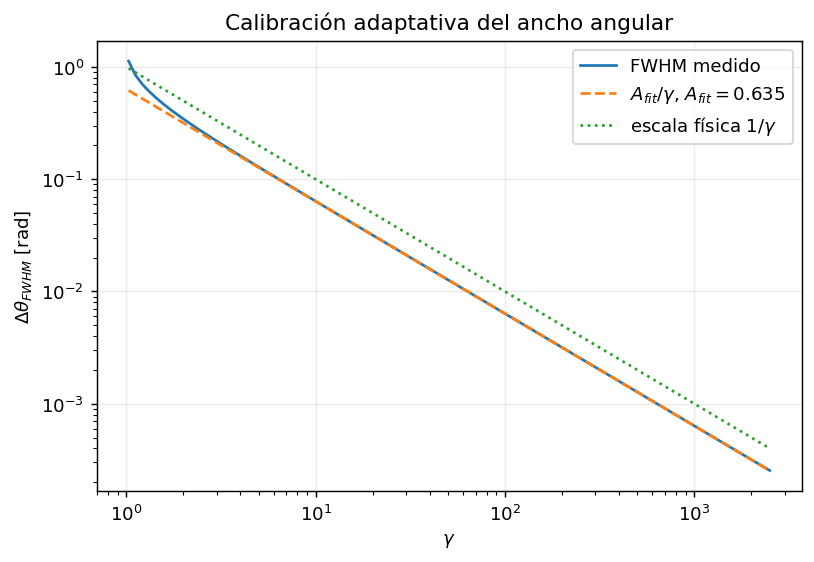

In [6]:
gamma_sweep = np.logspace(np.log10(1.03), np.log10(2500), 95)
width_sweep = np.array([adaptive_fwhm(g, n_points=7001) for g in gamma_sweep])
A_fit = np.median(width_sweep[gamma_sweep > 50] * gamma_sweep[gamma_sweep > 50])
print(f"A_fit = {A_fit:.4f} rad")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.loglog(gamma_sweep, width_sweep, label="FWHM medido")
ax.loglog(gamma_sweep, A_fit/gamma_sweep, "--", label=rf"$A_{{fit}}/\gamma$, $A_{{fit}}={A_fit:.3f}$")
ax.loglog(gamma_sweep, 1/gamma_sweep, ":", label=r"escala física $1/\gamma$")
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\Delta\theta_{FWHM}$ [rad]")
ax.set_title("Calibración adaptativa del ancho angular")
ax.legend()
savefig("fwhm_calibration.png")
plt.show()


### 3.6 Tiempo retardado y fase observada

La radiación observada no proviene de la posición instantánea de la carga, sino de su posición retardada. La relación geométrica de Liénard-Wiechert es

$$
t_{obs}=t_{ret}+\frac{|\mathbf r_{obs}-\mathbf r_q(t_{ret})|}{c}.
$$

En la simulación siguiente se usan unidades normalizadas con $c=1$. El retardo absoluto está dominado por la distancia geométrica al observador; lo que cambia de forma más relevante para la señal es el desfase orbital $\omega(t_{obs}-t_{ret})$. Ese desfase ayuda a entender por qué el observador recibe pulsos estrechos cuando la velocidad retardada apunta cerca de la línea de observación.


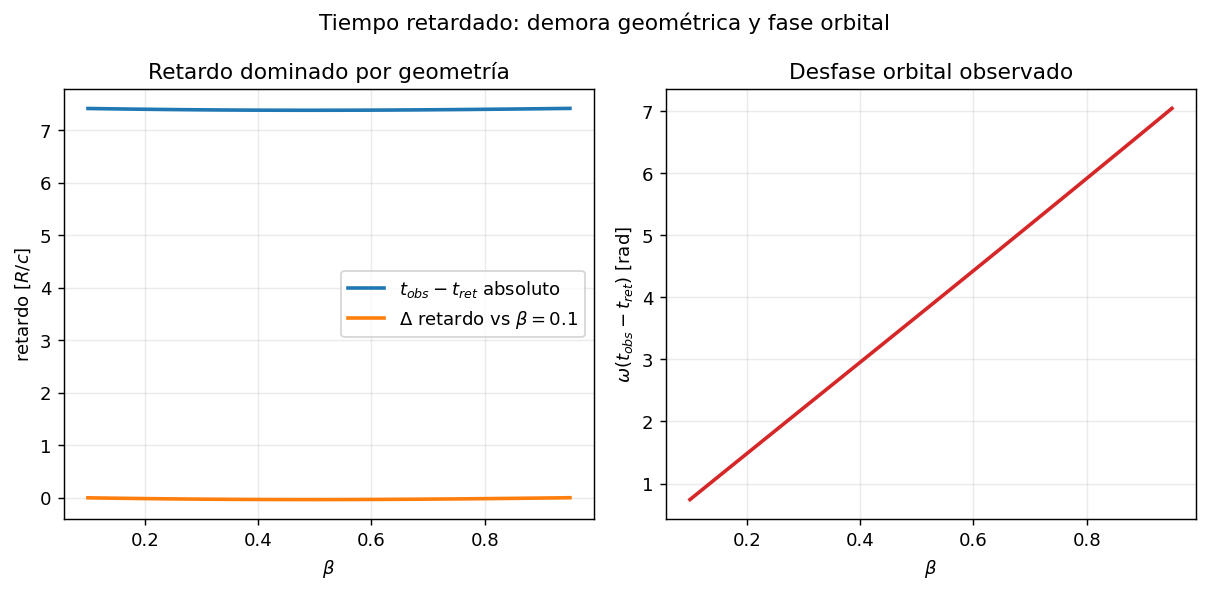

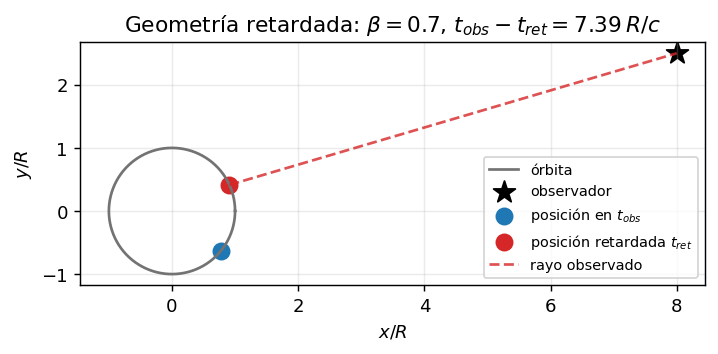

In [7]:
def rq_circular(t, beta=0.7, R=1.0):
    """Posición de una carga en órbita circular normalizada con c=1."""
    t = np.asarray(t, dtype=float)
    omega = beta / R
    return np.stack([R*np.cos(omega*t), R*np.sin(omega*t), np.zeros_like(t)], axis=-1)


def retarded_time_bisect(t_obs, r_obs, beta=0.7, R=1.0, tol=1e-11, max_iter=100):
    """Resuelve t_obs = t_ret + |r_obs-rq(t_ret)| por bisección."""
    r_obs = np.asarray(r_obs, dtype=float)

    def f(t_ret):
        distance = np.linalg.norm(r_obs - rq_circular(t_ret, beta=beta, R=R))
        return t_ret + distance - t_obs

    hi = t_obs
    lo = t_obs - np.linalg.norm(r_obs) - R - 10*R/max(beta, 1e-3)
    while f(lo) > 0:
        lo -= max(1.0, 2.0*abs(hi - lo))
    for _ in range(max_iter):
        mid = 0.5*(lo + hi)
        if f(mid) <= 0:
            lo = mid
        else:
            hi = mid
        if abs(hi - lo) < tol:
            break
    return 0.5*(lo + hi)

obs = np.array([8.0, 2.5, 0.0])
t_obs_demo = 8.0
ret_data = []
for beta in np.linspace(0.1, 0.95, 80):
    t_ret = retarded_time_bisect(t_obs_demo, obs, beta=beta)
    delay = t_obs_demo - t_ret
    phase_lag = beta * delay
    gamma_beta = 1.0 / np.sqrt(1.0 - beta**2)
    ret_data.append((beta, gamma_beta, delay, phase_lag))
ret_data = np.array(ret_data)

fig, axs = plt.subplots(1, 2, figsize=(9.4, 4.6))
axs[0].plot(ret_data[:, 0], ret_data[:, 2], lw=2, label=r"$t_{obs}-t_{ret}$ absoluto")
axs[0].plot(ret_data[:, 0], ret_data[:, 2] - ret_data[0, 2], lw=2, label=r"$\Delta$ retardo vs $\beta=0.1$")
axs[0].set_xlabel(r"$\beta$")
axs[0].set_ylabel(r"retardo [$R/c$]")
axs[0].set_title("Retardo dominado por geometría")
axs[0].legend(loc="best")
axs[1].plot(ret_data[:, 0], ret_data[:, 3], lw=2, color="tab:red")
axs[1].set_xlabel(r"$\beta$")
axs[1].set_ylabel(r"$\omega(t_{obs}-t_{ret})$ [rad]")
axs[1].set_title("Desfase orbital observado")
fig.suptitle("Tiempo retardado: demora geométrica y fase orbital")
fig.tight_layout()
savefig("retarded_time_vs_beta.png")
plt.show()

beta_demo = 0.7
t_ret_demo = retarded_time_bisect(t_obs_demo, obs, beta=beta_demo)
now = rq_circular(t_obs_demo, beta=beta_demo)
old = rq_circular(t_ret_demo, beta=beta_demo)
phase_path = np.linspace(0.0, 2*np.pi, 500)
fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.plot(np.cos(phase_path), np.sin(phase_path), color="0.45", lw=1.5, label="órbita")
ax.scatter([obs[0]], [obs[1]], marker="*", s=160, color="black", label="observador")
ax.scatter([now[0]], [now[1]], s=80, color="tab:blue", label=r"posición en $t_{obs}$")
ax.scatter([old[0]], [old[1]], s=80, color="tab:red", label=r"posición retardada $t_{ret}$")
ax.plot([old[0], obs[0]], [old[1], obs[1]], "--", color="tab:red", alpha=0.8, label="rayo observado")
ax.set_aspect("equal")
ax.set_xlabel(r"$x/R$")
ax.set_ylabel(r"$y/R$")
ax.set_title(fr"Geometría retardada: $\beta={beta_demo}$, $t_{{obs}}-t_{{ret}}={t_obs_demo-t_ret_demo:.2f}\,R/c$")
ax.legend(loc="best", fontsize=8)
savefig("retarded_position_geometry.png")
plt.show()


### 3.7 Asimetría adelante/atrás

Para radiación acelerada relativista, la concentración hacia adelante puede resumirse con la razón

$$\frac{P_{forward}}{P_{backward}}=\left(\frac{1+\beta}{1-\beta}\right)^3.$$


K        beta          P_forward/P_backward
 20 keV   0.27186591               5.3295e+00
100 keV   0.54822086               4.0246e+01
  1 MeV   0.94107923               3.5754e+04
100 MeV   0.99998708               3.7062e+15
  1 GeV   0.99999987               3.6057e+21


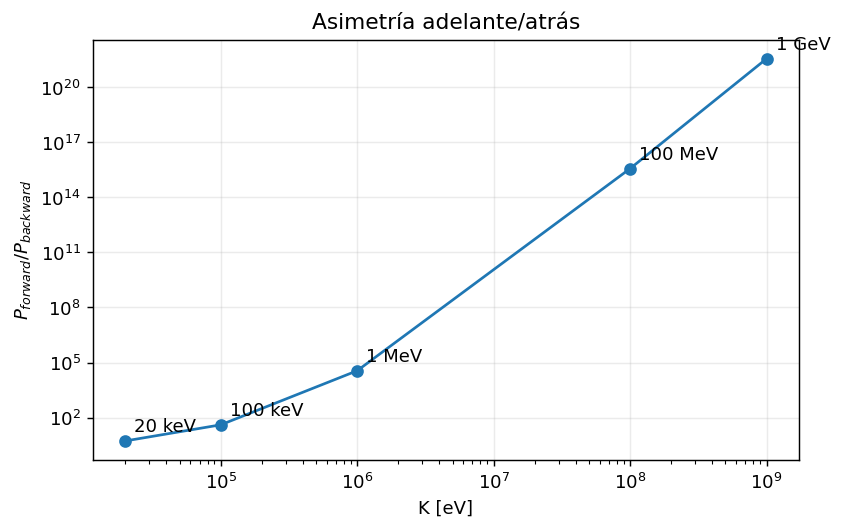

In [8]:
asymmetry = ((1 + betas_E) / (1 - betas_E))**3
print("K        beta          P_forward/P_backward")
for label, beta, ratio in zip(energy_labels, betas_E, asymmetry):
    print(f"{label:>7} {beta:12.8f} {ratio:24.4e}")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.semilogy(energies_eV, asymmetry, marker="o")
ax.set_xscale("log")
ax.set_xlabel("K [eV]")
ax.set_ylabel(r"$P_{forward}/P_{backward}$")
ax.set_title("Asimetría adelante/atrás")
for K, label, ratio in zip(energies_eV, energy_labels, asymmetry):
    ax.annotate(label, (K, ratio), textcoords="offset points", xytext=(5, 5))
savefig("forward_backward_asymmetry.png")
plt.show()


### 3.8 Potencia absoluta en SI

Para un electrón curvado por un campo magnético uniforme se usa

$$P=\frac{e^4B^2\gamma^2\beta^2}{6\pi\epsilon_0 m_e^2c}.$$

La emisión en un CRT existe en principio porque las cargas aceleradas irradian, pero es despreciable como fuente sincrotrón: lo visible en el dispositivo real es la energía depositada por impacto en el fósforo de la pantalla.


K        P [W]
 20 keV   1.2666e-19
100 keV   6.8194e-19
  1 MeV   1.2289e-17
100 MeV   6.1400e-14
  1 GeV   6.0841e-12


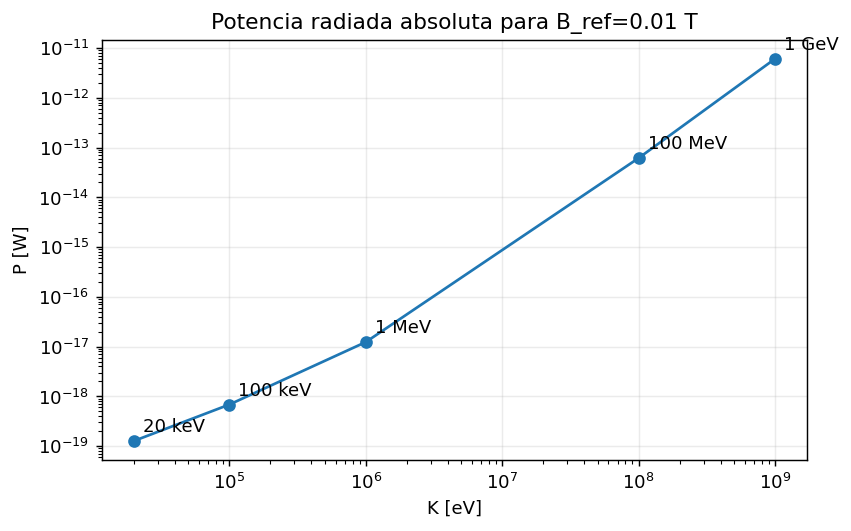

In [9]:
power_E = absolute_power_si(B_ref, gammas_E, betas_E)
print("K        P [W]")
for label, P in zip(energy_labels, power_E):
    print(f"{label:>7} {P:12.4e}")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.loglog(energies_eV, power_E, marker="o")
ax.set_xlabel("K [eV]")
ax.set_ylabel("P [W]")
ax.set_title(f"Potencia radiada absoluta para B_ref={B_ref:g} T")
for K, label, P in zip(energies_eV, energy_labels, power_E):
    ax.annotate(label, (K, P), textcoords="offset points", xytext=(5, 5))
savefig("absolute_power_si.png")
plt.show()


### 3.9 Escala espectral crítica

Se usa $m_c=\gamma^3$ como escala armónica adimensional y, en el régimen sincrotrón ultrarrelativista, la escala crítica convencional

$$\omega_c=\frac{3}{2}\gamma^3\omega_0.$$

Aquí $m_c$ y $\omega_c$ se usan como escalas diagnósticas; no son un sustituto del cálculo espectral completo ni un conteo exacto de líneas dominantes.


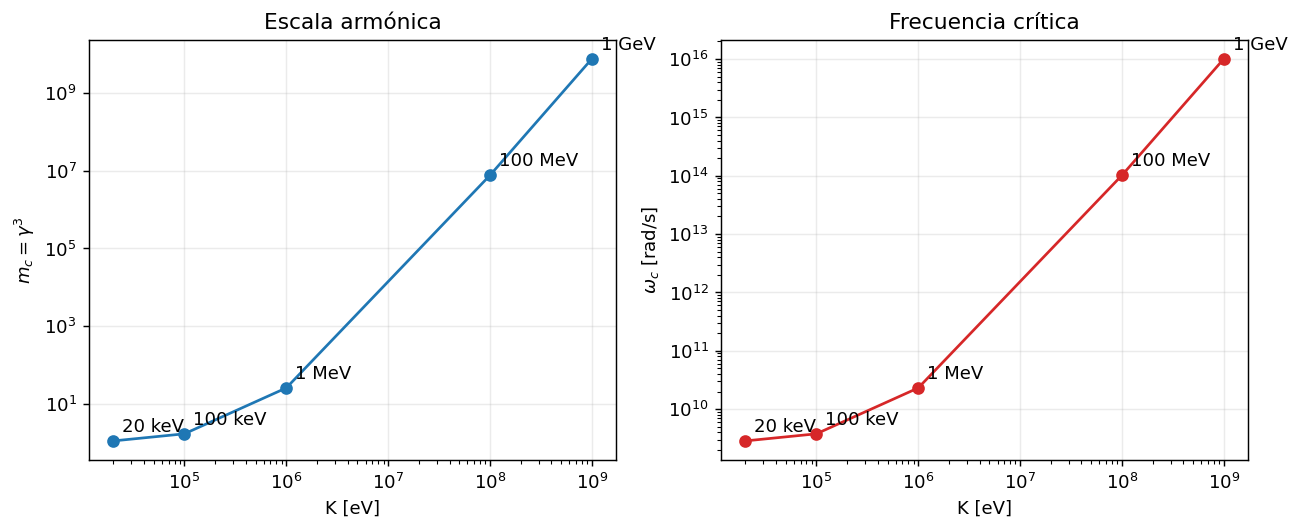

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax1.loglog(energies_eV, mc_E, marker="o")
ax1.set_xlabel("K [eV]")
ax1.set_ylabel(r"$m_c=\gamma^3$")
ax1.set_title("Escala armónica")
ax2.loglog(energies_eV, omega_c_E, marker="o", color="tab:red")
ax2.set_xlabel("K [eV]")
ax2.set_ylabel(r"$\omega_c$ [rad/s]")
ax2.set_title("Frecuencia crítica")
for ax in (ax1, ax2):
    for K, label in zip(energies_eV, energy_labels):
        y = mc_E[list(energies_eV).index(K)] if ax is ax1 else omega_c_E[list(energies_eV).index(K)]
        ax.annotate(label, (K, y), textcoords="offset points", xytext=(5, 5))
savefig("critical_frequency_scale.png")
plt.show()


### 3.10 FFT cualitativa de armónicos

Esta sección solo visualiza que pulsos temporales más estrechos contienen armónicos más altos. No reemplaza el espectro sincrotrón completo con teoría armónica y funciones de Bessel. Para evitar submuestreo se usan energías moderadas: 20 keV, 100 keV y 1 MeV.


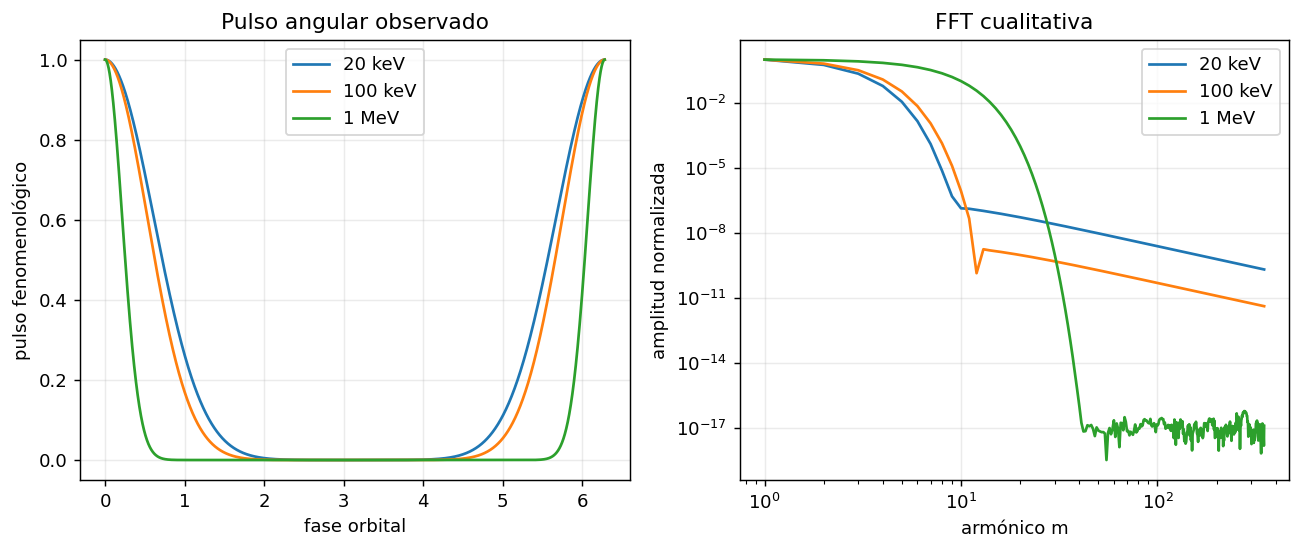

In [11]:
def wrapped_angle(x):
    return (x + np.pi) % (2*np.pi) - np.pi

n = 4096
phase = np.linspace(0, 2*np.pi, n, endpoint=False)
fig, (ax_t, ax_f) = plt.subplots(1, 2, figsize=(12, 4.4))
for K in [20e3, 100e3, 1e6]:
    g = gamma_from_kinetic_energy(K)
    width = max(0.08, A_fit/g)
    pulse = np.exp(-0.5 * (wrapped_angle(phase) / width)**2)
    pulse += np.exp(-0.5 * (wrapped_angle(phase - 2*np.pi) / width)**2)
    pulse /= pulse.max()
    spectrum = np.abs(np.fft.rfft(pulse - pulse.mean()))
    harmonic = np.fft.rfftfreq(n, d=1/n)
    ax_t.plot(phase, pulse, label=format_energy(K))
    ax_f.loglog(harmonic[1:350], spectrum[1:350] / spectrum[1:350].max(), label=format_energy(K))
ax_t.set_xlabel("fase orbital")
ax_t.set_ylabel("pulso fenomenológico")
ax_t.set_title("Pulso angular observado")
ax_t.legend()
ax_f.set_xlabel("armónico m")
ax_f.set_ylabel("amplitud normalizada")
ax_f.set_title("FFT cualitativa")
ax_f.legend()
savefig("fft_qualitative_harmonics.png")
plt.show()


### 3.11 Nota sobre el espectro sincrotrón completo

El espectro sincrotrón completo requiere funciones de Bessel/funciones especiales y cuidado con las convenciones de normalización, frecuencia crítica y variables adimensionales. Este notebook usa $m_c\sim\gamma^3$ y $\omega_c=(3/2)\gamma^3\omega_0$ solo como escalas diagnósticas; la FFT sigue siendo cualitativa.


### 3.12 Problema inverso: reconstrucción de energía

El observable angular estima `gamma` por beaming, mientras que el contenido espectral lo estima por armónicos. La consistencia entre ambos es una prueba diagnóstica: si discrepan más allá de incertidumbres, el modelo de haz monoenergético y divergencia simple probablemente no alcanza.


K true    gamma true   gamma_width  err_width[%]   gamma_mc   err_mc[%]   K_width[eV]   K_mc[eV]
  1 MeV       2.957        2.747         -7.11      2.924      -1.10   8.9263e+05   9.8338e+05
100 MeV     196.695      183.108         -6.91    189.145      -3.84   9.3057e+07   9.6142e+07
  1 GeV    1957.951     1883.088         -3.82   1921.053      -1.88   9.6174e+08   9.8114e+08


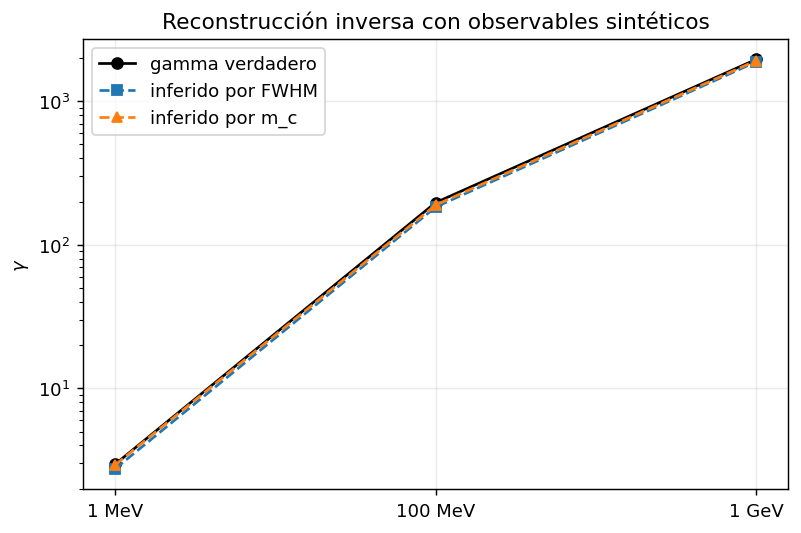

In [12]:
def infer_gamma_from_width(width_obs, A_fit):
    return A_fit / np.asarray(width_obs, dtype=float)


def infer_gamma_from_mc(mc_obs, factor=1.0):
    return (np.asarray(mc_obs, dtype=float) / factor)**(1.0/3.0)

true_K = np.array([1e6, 100e6, 1e9])
true_gamma = gamma_from_kinetic_energy(true_K)
true_width = np.array([adaptive_fwhm(g, n_points=8001) for g in true_gamma])
true_mc = true_gamma**3
width_obs = true_width * (1 + rng.normal(0, 0.05, size=true_width.shape))
mc_obs = true_mc * (1 + rng.normal(0, 0.05, size=true_mc.shape))

gamma_width = infer_gamma_from_width(width_obs, A_fit)
gamma_mc = infer_gamma_from_mc(mc_obs)
K_width = kinetic_energy_from_gamma(gamma_width)
K_mc = kinetic_energy_from_gamma(gamma_mc)
err_width = 100 * (gamma_width - true_gamma) / true_gamma
err_mc = 100 * (gamma_mc - true_gamma) / true_gamma

print("K true    gamma true   gamma_width  err_width[%]   gamma_mc   err_mc[%]   K_width[eV]   K_mc[eV]")
for row in zip(true_K, true_gamma, gamma_width, err_width, gamma_mc, err_mc, K_width, K_mc):
    print(f"{format_energy(row[0]):>7} {row[1]:11.3f} {row[2]:12.3f} {row[3]:13.2f} {row[4]:10.3f} {row[5]:10.2f} {row[6]:12.4e} {row[7]:12.4e}")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
idx = np.arange(len(true_K))
ax.plot(idx, true_gamma, "ko-", label="gamma verdadero")
ax.plot(idx, gamma_width, "s--", label="inferido por FWHM")
ax.plot(idx, gamma_mc, "^--", label="inferido por m_c")
ax.set_xticks(idx, [format_energy(K) for K in true_K])
ax.set_ylabel(r"$\gamma$")
ax.set_yscale("log")
ax.set_title("Reconstrucción inversa con observables sintéticos")
ax.legend()
savefig("inverse_diagnostic_reconstruction.png")
plt.show()


### 3.13 Estimación de divergencia angular del haz

Si `gamma` se conoce por el observable espectral, el ancho radiativo esperado puede escribirse como una desviación equivalente

$$\sigma_{rad}=\frac{A_{fit}/\gamma_{mc}}{2\sqrt{2\ln 2}},$$

cuando `Delta theta_obs` se midió como FWHM. La divergencia angular del haz se estima por desconvolución cuadrática:

$$\sigma_b\approx \sqrt{\max(0,\sigma_{obs}^2-\sigma_{rad}^2)}.$$

Este modelo es 1D: representa un corte angular efectivo. Un haz real requiere una distribución angular 2D y la respuesta angular/espectral del detector para una inferencia cuantitativa.


sigma_beam true [rad]   FWHM_obs [rad]   sigma_b estimada [rad]
           0.0000e+00       3.2400e-03              1.1074e-04
           2.5420e-03       6.8400e-03              2.5605e-03
           5.0840e-03       1.2480e-02              5.1192e-03


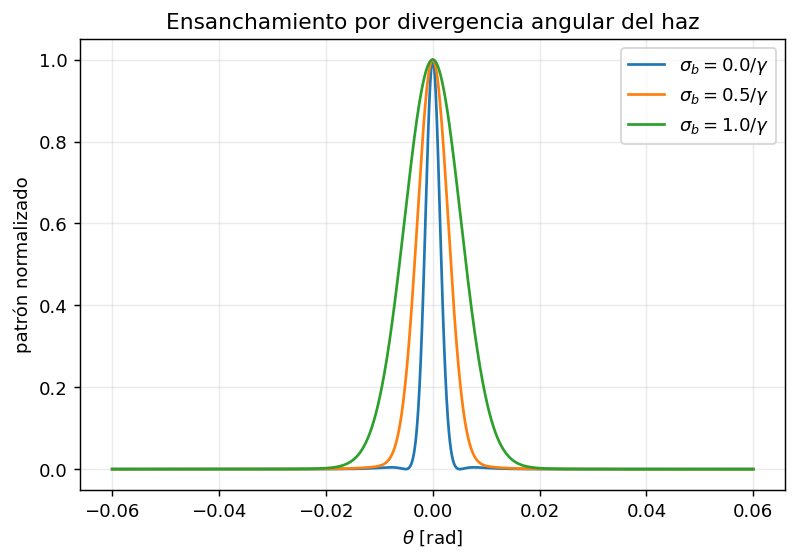

In [13]:
def gaussian_kernel(theta_grid, sigma):
    if sigma <= 0:
        k = np.zeros_like(theta_grid)
        k[len(k)//2] = 1.0
        return k
    k = np.exp(-0.5 * (theta_grid / sigma)**2)
    return k / k.sum()


def broaden_pattern(theta_grid, gamma, sigma_beam):
    base = normalized_angular_power(np.abs(theta_grid), gamma=gamma)
    kernel = gaussian_kernel(theta_grid, sigma_beam)
    broadened = np.convolve(base, kernel, mode="same")
    return broadened / broadened.max()


def fwhm_from_grid(theta_grid, y):
    y = y / y.max()
    center = int(np.argmax(y))
    half = 0.5
    left = np.where(y[:center] <= half)[0]
    right = np.where(y[center:] <= half)[0]
    l = theta_grid[left[-1]] if len(left) else theta_grid[0]
    r = theta_grid[center + right[0]] if len(right) else theta_grid[-1]
    return r - l

gamma_div = gamma_from_kinetic_energy(100e6)
theta_div = np.linspace(-0.06, 0.06, 6001)
cases = [0.0, 0.5/gamma_div, 1.0/gamma_div]
fig, ax = plt.subplots(figsize=(7.0, 4.5))
print("sigma_beam true [rad]   FWHM_obs [rad]   sigma_b estimada [rad]")
for sigma_beam in cases:
    y = broaden_pattern(theta_div, gamma_div, sigma_beam)
    fwhm_obs = fwhm_from_grid(theta_div, y)
    sigma_obs = fwhm_obs / (2*np.sqrt(2*np.log(2)))
    gamma_from_mc = gamma_div
    sigma_rad = (A_fit / gamma_from_mc) / (2*np.sqrt(2*np.log(2)))
    sigma_est = np.sqrt(max(0.0, sigma_obs**2 - sigma_rad**2))
    ax.plot(theta_div, y, label=rf"$\sigma_b={sigma_beam*gamma_div:.1f}/\gamma$")
    print(f"{sigma_beam:21.4e} {fwhm_obs:16.4e} {sigma_est:23.4e}")
ax.set_xlabel(r"$\theta$ [rad]")
ax.set_ylabel("patrón normalizado")
ax.set_title("Ensanchamiento por divergencia angular del haz")
ax.legend()
savefig("beam_divergence_broadening.png")
plt.show()


## 4. Análisis y aplicaciones

### 4.1 Interpretación física global

El desarrollo muestra cómo el mismo sistema de carga curvada cambia de régimen cuando aumenta $\gamma$: el patrón angular se estrecha, la asimetría adelante/atrás crece y la escala espectral se desplaza hacia armónicos más altos. Esa combinación permite plantear el diagnóstico inverso de energía y divergencia del haz.

### 4.2 Comparación de regímenes: CRT, MeV y GeV

En energías tipo CRT, el haz sirve para visualizar deflexión de cargas por fuerza de Lorentz, pero la emisión sincrotrón no es una señal práctica. En MeV aparecen correcciones relativistas visibles. En 100 MeV y 1 GeV domina el beaming delantero y la escala $m_c\sim\gamma^3$ entra en el régimen sincrotrón relativista claro.

### 4.3 Aplicación tipo CRT: deflexión y pantalla

Un CRT acelera electrones con decenas de kilovoltios y los desvía con campos eléctricos o magnéticos. Esa geometría es útil para visualizar una partícula cargada curvada por fuerza de Lorentz, pero no para producir radiación sincrotrón intensa.

**El CRT es una analogía de deflexión de haces cargados, no una fuente útil de radiación sincrotrón.** La imagen visible en la pantalla es el punto donde el haz golpea el fósforo; por eso la visualización siguiente modela deflexión, barrido y persistencia fosfórica, no radiación sincrotrón útil.


K          gamma        beta        P(B fijo)/P_20keV    omega_c/omega_c20
 20 keV       1.0391    0.271866         1.0000e+00         1.0000e+00
100 keV       1.1957    0.548221         5.3839e+00         1.3240e+00
  1 MeV       2.9570    0.941079         9.7025e+01         8.0973e+00
100 MeV     196.6951    0.999987         4.8475e+05         3.5829e+04
  1 GeV    1957.9512    1.000000         4.8034e+07         3.5502e+06


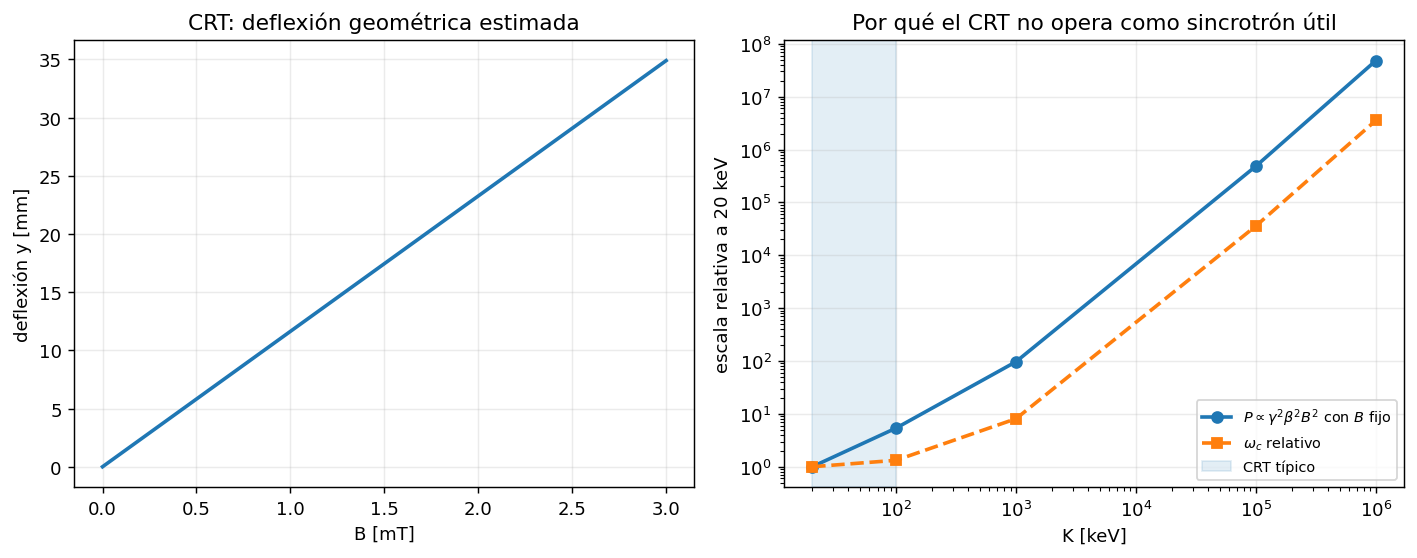

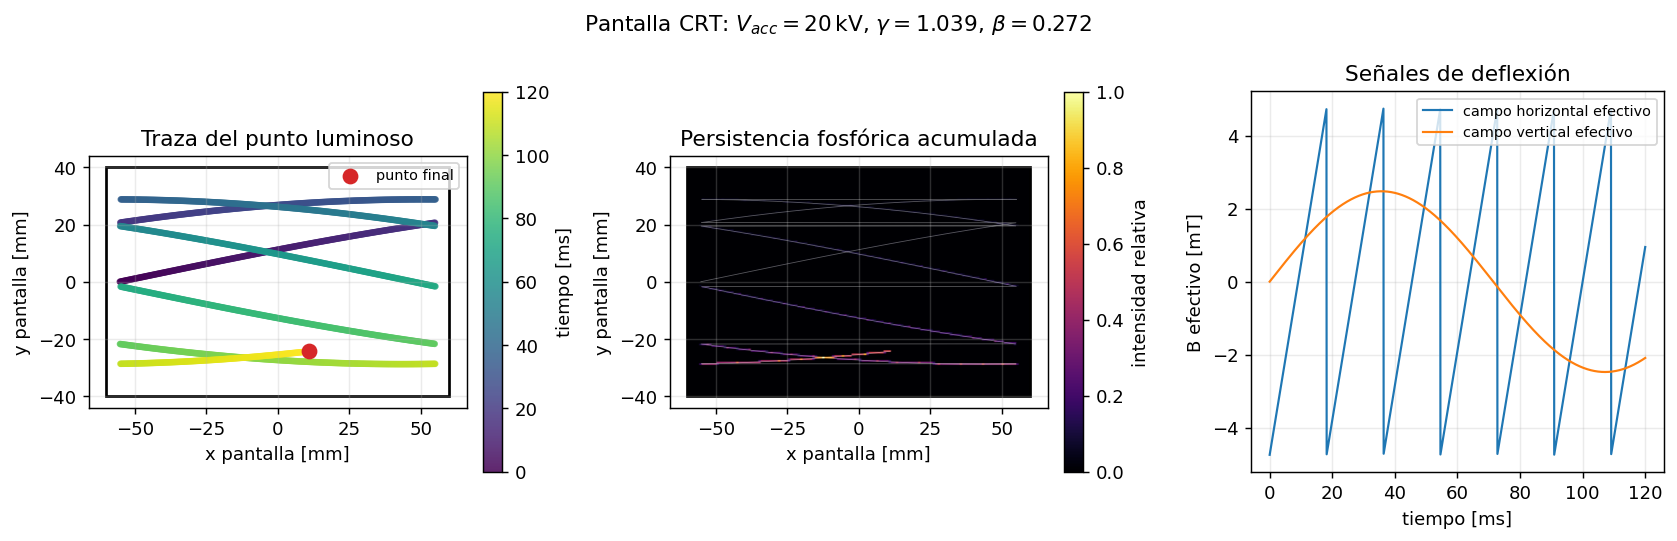

In [14]:
def crt_deflection(B_T, K_eV=20e3, L_b=0.04, L_d=0.12):
    gamma = gamma_from_kinetic_energy(K_eV)
    beta = beta_from_gamma(gamma)
    v = beta * c
    return e_abs * B_T / (gamma * m_e * v) * (L_b*L_d + 0.5*L_b**2)

B_values = np.linspace(0, 3e-3, 120)
y_values = crt_deflection(B_values)
fixed_B_power_scale = gammas_E**2 * betas_E**2
fixed_B_power_scale /= fixed_B_power_scale[0]

print("K          gamma        beta        P(B fijo)/P_20keV    omega_c/omega_c20")
for label, g, b, p_rel, wc_rel in zip(energy_labels, gammas_E, betas_E, fixed_B_power_scale, omega_c_E/omega_c_E[0]):
    print(f"{label:>7}  {g:11.4f}  {b:10.6f}  {p_rel:17.4e}  {wc_rel:17.4e}")

fig, axs = plt.subplots(1, 2, figsize=(11.0, 4.4))
axs[0].plot(B_values*1e3, y_values*1e3, lw=2)
axs[0].set_xlabel("B [mT]")
axs[0].set_ylabel("deflexión y [mm]")
axs[0].set_title("CRT: deflexión geométrica estimada")
axs[1].loglog(energies_eV/1e3, fixed_B_power_scale, "o-", lw=2, label=r"$P\propto\gamma^2\beta^2B^2$ con $B$ fijo")
axs[1].loglog(energies_eV/1e3, omega_c_E/omega_c_E[0], "s--", lw=2, label=r"$\omega_c$ relativo")
axs[1].axvspan(20, 100, color="tab:blue", alpha=0.12, label="CRT típico")
axs[1].set_xlabel("K [keV]")
axs[1].set_ylabel("escala relativa a 20 keV")
axs[1].set_title("Por qué el CRT no opera como sincrotrón útil")
axs[1].legend(fontsize=8)
fig.tight_layout()
savefig("crt_deflection_and_scales.png")
plt.show()

V_acc = 20e3
L_b = 0.04
L_d = 0.12
screen_width = 0.12
screen_height = 0.08
scan_frequency = 55.0
vertical_frequency = 7.0
duration = 0.12
samples = 1800
t_screen = np.linspace(0.0, duration, samples)

gamma_crt = float(gamma_from_kinetic_energy(V_acc))
beta_crt = float(beta_from_gamma(gamma_crt))
v_crt = beta_crt * c
deflection_sensitivity = e_abs / (gamma_crt * m_e * v_crt) * (L_b*L_d + 0.5*L_b**2)

x_target = 0.46 * screen_width
y_target = 0.36 * screen_height
scan_phase = (scan_frequency * t_screen) % 1.0
x_signal = 2.0 * scan_phase - 1.0
y_signal = np.sin(2*np.pi*vertical_frequency*t_screen)

B_horizontal = x_target * x_signal / deflection_sensitivity
B_vertical = y_target * y_signal / deflection_sensitivity
x_screen = crt_deflection(B_horizontal, K_eV=V_acc, L_b=L_b, L_d=L_d)
y_screen = crt_deflection(B_vertical, K_eV=V_acc, L_b=L_b, L_d=L_d)

tau_phosphor = 0.030
weights = np.exp(-(t_screen[-1] - t_screen) / tau_phosphor)
heatmap, x_edges, y_edges = np.histogram2d(
    x_screen,
    y_screen,
    bins=140,
    range=[[-screen_width/2, screen_width/2], [-screen_height/2, screen_height/2]],
    weights=weights,
)
heatmap = heatmap / heatmap.max()
extent = [x_edges[0]*1e3, x_edges[-1]*1e3, y_edges[0]*1e3, y_edges[-1]*1e3]

fig, axs = plt.subplots(1, 3, figsize=(13.0, 4.2), gridspec_kw={"width_ratios": [1.0, 1.0, 1.0]})
for ax in axs[:2]:
    boundary = plt.Rectangle(
        (-screen_width/2*1e3, -screen_height/2*1e3),
        screen_width*1e3,
        screen_height*1e3,
        fill=False,
        lw=1.5,
        edgecolor="black",
    )
    ax.add_patch(boundary)
    ax.set_aspect("equal")
    ax.set_xlim(-screen_width*0.55*1e3, screen_width*0.55*1e3)
    ax.set_ylim(-screen_height*0.55*1e3, screen_height*0.55*1e3)
    ax.set_xlabel("x pantalla [mm]")
    ax.set_ylabel("y pantalla [mm]")

trace = axs[0].scatter(x_screen*1e3, y_screen*1e3, c=t_screen*1e3, s=7, cmap="viridis", alpha=0.85)
axs[0].scatter([x_screen[-1]*1e3], [y_screen[-1]*1e3], s=60, color="tab:red", label="punto final")
axs[0].set_title("Traza del punto luminoso")
axs[0].legend(loc="upper right", fontsize=8)
fig.colorbar(trace, ax=axs[0], fraction=0.046, pad=0.04, label="tiempo [ms]")

image = axs[1].imshow(heatmap.T, origin="lower", extent=extent, cmap="inferno", aspect="equal", vmin=0.0, vmax=1.0)
axs[1].plot(x_screen*1e3, y_screen*1e3, color="white", lw=0.45, alpha=0.35)
axs[1].set_title("Persistencia fosfórica acumulada")
fig.colorbar(image, ax=axs[1], fraction=0.046, pad=0.04, label="intensidad relativa")

axs[2].plot(t_screen*1e3, B_horizontal*1e3, lw=1.2, label="campo horizontal efectivo")
axs[2].plot(t_screen*1e3, B_vertical*1e3, lw=1.2, label="campo vertical efectivo")
axs[2].set_xlabel("tiempo [ms]")
axs[2].set_ylabel("B efectivo [mT]")
axs[2].set_title("Señales de deflexión")
axs[2].legend(fontsize=8)
fig.suptitle(fr"Pantalla CRT: $V_{{acc}}={V_acc/1e3:.0f}\,\mathrm{{kV}}$, $\gamma={gamma_crt:.3f}$, $\beta={beta_crt:.3f}$")
fig.tight_layout()
savefig("crt_screen_persistence_heatmap.png")
plt.show()


### 4.4 Limitaciones del modelo

**Limitaciones principales:** se usa una distribución angular instantánea de Liénard-Wiechert, el haz se modela con una divergencia gaussiana 1D y la FFT sigue siendo cualitativa. Un cálculo sincrotrón espectral completo requiere funciones especiales/Bessel, cuidado de convenciones y un modelo temporal/geométrico de observación más detallado.

### 4.5 Conclusiones físicas

**Respuesta:** sí, bajo supuestos controlados puede reconstruirse la energía relativista y estimarse la divergencia angular del haz a partir del patrón angular y del contenido espectral.

1. En $20\,\mathrm{keV}$, típico de CRT, $\gamma=1.039$ y $\beta=0.272$: el patrón sigue siendo ancho, la escala armónica es baja y el dispositivo sirve como analogía de deflexión, no como sincrotrón.

2. En $100\,\mathrm{keV}$, $\gamma=1.196$ y $\beta=0.548$: aparecen correcciones relativistas visibles, pero todavía no hay un cono estrecho dominante.

3. En $1\,\mathrm{MeV}$, $\gamma=2.957$ y $\beta=0.941$: el FWHM escala como $A_{fit}/\gamma$ y ya muestra una transición angular visible respecto del patrón dipolar.

4. En $100\,\mathrm{MeV}$ y $1\,\mathrm{GeV}$, $\gamma\gg1$: el lóbulo se comprime fuertemente hacia adelante y $m_c\sim\gamma^3$ crece hasta órdenes muy altos, que es el régimen sincrotrón relativista claro.

5. En el problema inverso, la reconstrucción de energía es consistente cuando la estimación angular de `gamma` y la estimación espectral por `m_c` coinciden dentro de las incertidumbres.

6. La divergencia angular del haz puede estimarse por desconvolución cuadrática del ancho observado: se resta en varianza el ancho radiativo esperado y se interpreta el residuo como divergencia del haz.

## 5. Referencias

- Milton & Schwinger. *Classical Electrodynamics*, 2nd ed., capítulos 34, 35, 38, 41 y 43.
- Jackson, J. D. *Classical Electrodynamics*, 3rd ed.
- Griffiths, D. J. *Introduction to Electrodynamics*.
- NIST/CODATA. Valores recomendados de constantes físicas fundamentales usados para $c$, $m_e$, $e$ y $\epsilon_0$.
